In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from skimage.io import imread
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# set a deterministic seed
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# base paths (adjust if necessary)
BASE_PATH = "../input/aerial-cactus-identification"
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "train")
TEST_IMG_DIR = os.path.join(BASE_PATH, "test")
TRAIN_CSV = os.path.join(BASE_PATH, "train.csv")
TEST_CSV = os.path.join(BASE_PATH, "sample_submission.csv")  # contains test ids

print("Listing root:", os.listdir("../input"))
print("Train dir files:", len(os.listdir(TRAIN_IMG_DIR)))
print("Test dir files:", len(os.listdir(TEST_IMG_DIR)))



2026-05-06 08:17:19.824628: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778055439.833972      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778055439.838049      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-06 08:17:19.854322: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Listing root: ['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']
Train dir files: 14176
Test dir files: 3326


In [2]:
# Load labels
train_df = pd.read_csv(TRAIN_CSV)
print("Train samples:", train_df.shape[0])


# Helper to load images given a list of ids
def load_images(ids, img_dir):
    imgs = []
    for img_id in ids:
        path = os.path.join(img_dir, img_id)
        img = imread(path)  # shape (32,32,3)
        if img.shape != (32, 32, 3):
            # some images may be grayscale; convert to 3‑channel
            img = np.stack([img] * 3, axis=-1)
        imgs.append(img)
    return np.array(imgs, dtype=np.float32) / 255.0  # normalize


# Load training images
X = load_images(train_df["id"].values, TRAIN_IMG_DIR)
y = train_df["has_cactus"].values.astype(np.float32)

# Split for validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=seed, stratify=y
)

print("Train/Val shapes:", X_train.shape, X_val.shape)



Train samples: 14175
Train/Val shapes: (12757, 32, 32, 3) (1418, 32, 32, 3)


In [3]:
# Build a small CNN (keeps core idea of a model with pooling & dense layers)
inp = Input(shape=(32, 32, 3))
x = Conv2D(32, (3, 3), activation="relu", padding="same")(inp)
x = MaxPooling2D()(x)
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D()(x)
x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
out = Dense(1, activation="sigmoid")(x)

model = Model(inputs=inp, outputs=out)

# Compile with same loss/optimizer as original script
model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.0001),
    metrics=["accuracy"],
)

model.summary()



2026-05-06 08:17:36.871144: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778055456.871599      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:46:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Callbacks similar to original code
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.1, patience=5, verbose=1, min_lr=1e-7
)
early_stop = EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[reduce_lr, early_stop],
    verbose=2,
)



Epoch 1/30


I0000 00:00:1778055458.403920     109 service.cc:148] XLA service 0x7f721400afe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778055458.403951     109 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-06 08:17:38.426299: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778055458.537238     109 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1778055459.555323     109 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 - 4s - 18ms/step - accuracy: 0.7485 - loss: 0.5124 - val_accuracy: 0.7496 - val_loss: 0.3871 - learning_rate: 1.0000e-04
Epoch 2/30
200/200 - 0s - 2ms/step - accuracy: 0.8829 - loss: 0.2704 - val_accuracy: 0.9386 - val_loss: 0.1740 - learning_rate: 1.0000e-04
Epoch 3/30
200/200 - 0s - 2ms/step - accuracy: 0.9247 - loss: 0.1905 - val_accuracy: 0.9408 - val_loss: 0.1599 - learning_rate: 1.0000e-04
Epoch 4/30
200/200 - 0s - 2ms/step - accuracy: 0.9272 - loss: 0.1831 - val_accuracy: 0.9401 - val_loss: 0.1559 - learning_rate: 1.0000e-04
Epoch 5/30
200/200 - 0s - 2ms/step - accuracy: 0.9285 - loss: 0.1782 - val_accuracy: 0.9401 - val_loss: 0.1537 - learning_rate: 1.0000e-04
Epoch 6/30
200/200 - 0s - 2ms/step - accuracy: 0.9310 - loss: 0.1746 - val_accuracy: 0.9394 - val_loss: 0.1495 - learning_rate: 1.0000e-04
Epoch 7/30
200/200 - 0s - 2ms/step - accuracy: 0.9320 - loss: 0.1724 - val_accuracy: 0.9386 - val_loss: 0.1476 - learning_rate: 1.0000e-04
Epoch 8/30
200/200 - 0s - 2ms/step - 

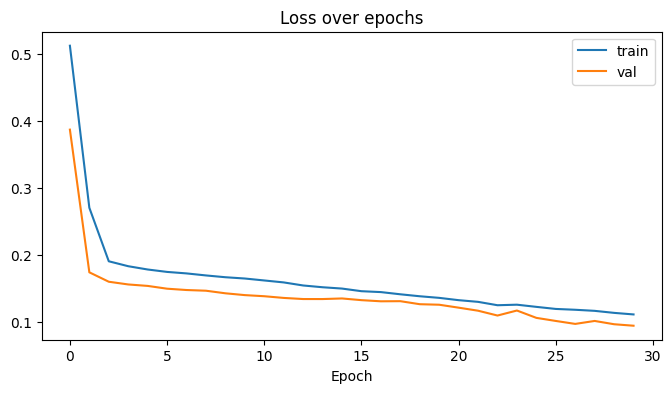

In [5]:
# Plot training curves (optional, harmless if not displayed)
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.legend()
plt.show()



In [6]:
# Load test ids and images
test_df = pd.read_csv(TEST_CSV)  # contains column 'id'
X_test = load_images(test_df["id"].values, TEST_IMG_DIR)

# Predict probabilities
preds = model.predict(X_test, batch_size=64, verbose=0).ravel()
test_df["has_cactus"] = preds



In [7]:
# Write submission file with correct column order
submission_path = "submission.csv"
test_df[["id", "has_cactus"]].to_csv(submission_path, index=False)
print(f"Submission written to {submission_path}")
print(test_df.head())

Submission written to submission.csv
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg    0.965472
1  134f04305c795d6d202502c2ce3578f3.jpg    0.999965
2  41fad8d145e6c41868ce3617e30a2545.jpg    0.999916
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg    0.998620
4  b77dc902b035887cbbc01920ce0e3151.jpg    0.999582
